## Módulo 19 - Transformação de Variáveis


# Projeto de Regressão Linear: Precificação de Imóveis

## Objetivo
Estimar preços dos imóveis de acordo com diversas características das propriedades, como área e localização. Para este propósito, vamos:

* **Identificar** quais fatores contribuem para a precificação dos imóveis;
* **Averiguar** a influência das características no preço do imóvel;
* **Diferenciar** quando precisamos transformar ou não as variáveis para uma melhor resposta do modelo;
* **Verificar** a relação entre as variáveis explicativas e a variável resposta;
* **Criar** um modelo de regressão linear de múltiplas variáveis;
* **Fazer** previsões para uma ou mais casas.

## Base de Dados
Vamos utilizar a base `precos_casa.csv`, adaptada de uma base bem conhecida no Kaggle chamada [House Prices](https://kaggle.com). Esses dados serão lidos a partir do repositório compartilhado pelo GitHub.


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [14]:
# Alternativa caso o link falhe: usando seu arquivo local
dados = pd.read_csv(r'Dados\precos_casas.csv')

# Filtrando e ordenando as colunas
ordem_colunas = ['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal', 'dist_metro', 'dist_parque']
dados = dados[ordem_colunas].round(2)
dados.head()




,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
0,1042500,79.52,1,23.86,1.64,3.04
1,907500,117.24,0,35.17,1.54,10.91
2,1117500,85.47,1,25.64,1.27,11.79
3,700000,89.28,1,21.07,1.22,10.88
4,1250000,106.37,1,31.91,0.87,11.25


In [15]:
dados.shape

(1460, 6)

In [16]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor                 1460 non-null   int64  
 1   area_primeiro_andar   1460 non-null   float64
 2   existe_segundo_andar  1460 non-null   int64  
 3   area_quintal          1460 non-null   float64
 4   dist_metro            1460 non-null   float64
 5   dist_parque           1460 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 68.6 KB


# 1.3 - Entendendo a relação dos dados

Para entender a relação dos dados entre o valor de venda dos imóveis do dataset e suas características vamos utilizar a **Correlação**.

Correlação é uma medida estatística que varia numa escala de -1 a 1, indicando a relação e a dependência entre duas variáveis. Existem três tipos principais de correlação:

1. **Correlação Positiva**: quando uma variável aumenta, a outra tende a aumentar.
2. **Correlação Nula**: não há relação linear entre as variáveis.
3. **Correlação Negativa**: quando uma variável aumenta, a outra tende a diminuir.

Essa medida não só define a direção, como também, a intensidade da relação.


In [17]:
# .corr(): Calcula os coeficientes de correlação linear entre todas as colunas numéricas
# .round(3): Arredonda os valores resultantes para exibir exatamente 3 casas decimais
corr = dados.corr().round(3)

# Exibe a matriz de correlação gerada na tela do notebook
corr


,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
valor,1.000,0.606,0.138,0.614,-0.644,-0.072
area_primeiro_andar,0.606,1.000,-0.339,0.820,-0.369,-0.058
existe_segundo_andar,0.138,-0.339,1.000,-0.301,-0.191,-0.007
area_quintal,0.614,0.820,-0.301,1.000,-0.440,-0.058
dist_metro,-0.644,-0.369,-0.191,-0.440,1.000,0.089
dist_parque,-0.072,-0.058,-0.007,-0.058,0.089,1.000


In [18]:
# corr["valor"]: Filtra apenas a coluna de preço ('valor') dentro da matriz de correlação
# .to_frame(): Transforma a série resultante em uma tabela (DataFrame) para ficar mais visual
corr["valor"].to_frame()


,valor
valor,1.000
area_primeiro_andar,0.606
existe_segundo_andar,0.138
area_quintal,0.614
dist_metro,-0.644
dist_parque,-0.072


# 1.4 - Visualizando uma Regressão Linear com uma variável independente

Já compreendemos um pouco a relação entre as variáveis e o valor de venda das casas. Mas que tal observarmos isso visualmente, pegando apenas uma das variáveis de nossa base?

>Aqui vamos apenas observar o comportamento da variável `valor` em relação a `area_primeiro_andar` rodando um modelo de regressão linear dentro da função `reg_plot()` da biblioteca `seaborn`. Mais a frente implementaremos o nosso próprio modelo!


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

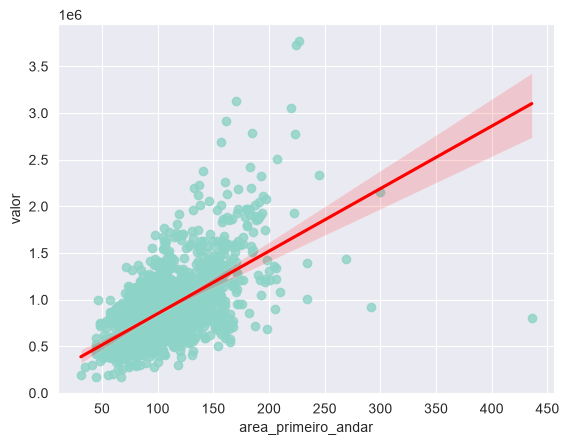

In [20]:
sns.set_style("darkgrid")
sns.regplot(x="area_primeiro_andar", y="valor", data=dados, line_kws={'color':'red'})
plt.show()

In [21]:
# Importa as ferramentas necessárias para renderizar Markdown dentro do código Python
from IPython.display import display, Markdown

# Armazena todo o texto explicativo e as fórmulas em formato string
conteudo_teorico = """
### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \\beta_0 + \\beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).
"""

# Renderiza e exibe o bloco formatado perfeitamente na tela
display(Markdown(conteudo_teorico))



### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \beta_0 + \beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).


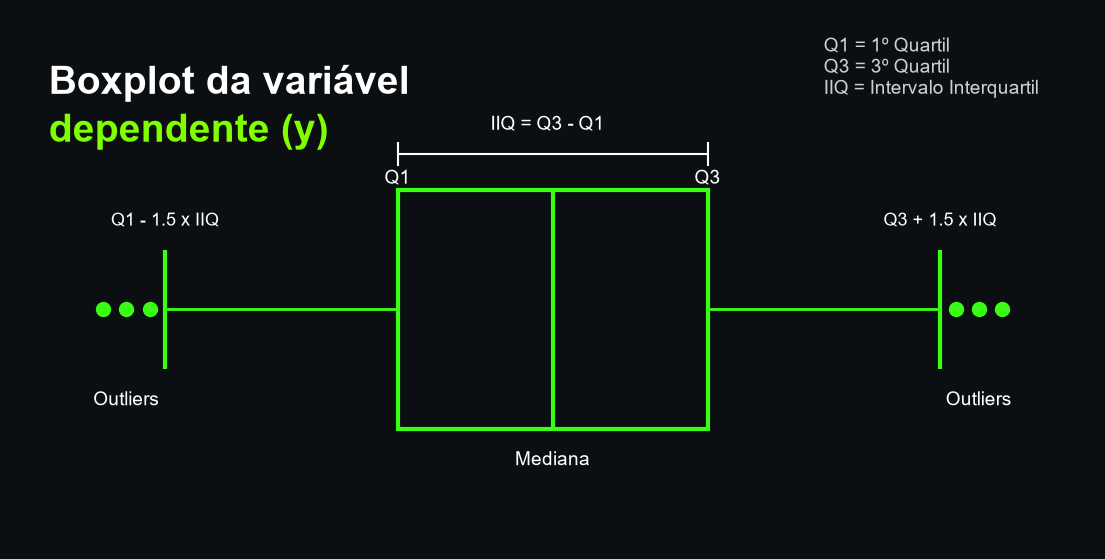

In [22]:
import base64
import io
import matplotlib.pyplot as plt


def gerar_layout_boxplot():
    # Define o estilo visual escuro idêntico ao slide do curso
    plt.style.use("dark_background")

    # Cria a figura com um tamanho grande e nítido
    fig, ax = plt.subplots(figsize=(14, 7), facecolor="#0B0F12")
    ax.set_facecolor("#0B0F12")

    # Desenha a caixa principal do Boxplot (Verde Neon)
    # Q1 = 4, Mediana = 6, Q3 = 8
    rect = plt.Rectangle(
        (4, 2), 4, 2, edgecolor="#39FF14", facecolor="none", linewidth=3
    )
    ax.add_patch(rect)

    # Linha da Mediana
    ax.vlines(6, 2, 4, colors="#39FF14", linewidth=3)

    # Bigodes (Whiskers) e Limites (Q1 - 1.5*IIQ = 1 e Q3 + 1.5*IIQ = 11)
    ax.hlines(3, 1, 4, colors="#39FF14", linewidth=2)
    ax.hlines(3, 8, 11, colors="#39FF14", linewidth=2)
    ax.vlines(1, 2.5, 3.5, colors="#39FF14", linewidth=3)  # Limite Inferior
    ax.vlines(11, 2.5, 3.5, colors="#39FF14", linewidth=3)  # Limite Superior

    # Desenha os Outliers (Pontos Verdes além dos limites)
    ax.scatter([0.2, 0.5, 0.8], [3, 3, 3], color="#39FF14", s=100)
    ax.scatter([11.2, 11.5, 11.8], [3, 3, 3], color="#39FF14", s=100)

    # ---- TEXTOS E LEGENDA DO LAYOUT ----

    # Título principal do slide
    ax.text(
        -0.5,
        4.8,
        "Boxplot da variável",
        fontsize=28,
        weight="bold",
        color="white",
    )
    ax.text(
        -0.5,
        4.4,
        "dependente (y)",
        fontsize=28,
        weight="bold",
        color="#7FFF00",
    )

    # Equações e Legendas Estatísticas (Canto Superior Direito)
    ax.text(
        9.5,
        4.8,
        "Q1 = 1º Quartil\nQ3 = 3º Quartil\nIIQ = Intervalo Interquartil",
        fontsize=14,
        color="white",
        alpha=0.8,
    )

    # Linha e texto do IIQ (Intervalo Interquartil)
    ax.hlines(4.3, 4, 8, colors="white", linewidth=1.5)
    ax.vlines(4, 4.2, 4.4, colors="white", linewidth=1.5)
    ax.vlines(8, 4.2, 4.4, colors="white", linewidth=1.5)
    ax.text(5.2, 4.5, "IIQ = Q3 - Q1", fontsize=14, color="white")

    # Textos das marcações dos Quartis e Limites
    ax.text(4, 4.05, "Q1", fontsize=14, color="white", ha="center")
    ax.text(8, 4.05, "Q3", fontsize=14, color="white", ha="center")
    ax.text(6, 1.7, "Mediana", fontsize=14, color="white", ha="center")

    # Fórmulas dos limites nas pontas dos bigodes
    ax.text(1, 3.7, "Q1 - 1.5 x IIQ", fontsize=13, color="white", ha="center")
    ax.text(11, 3.7, "Q3 + 1.5 x IIQ", fontsize=13, color="white", ha="center")

    # Rótulos de Outliers
    ax.text(0.5, 2.2, "Outliers", fontsize=14, color="white", ha="center")
    ax.text(11.5, 2.2, "Outliers", fontsize=14, color="white", ha="center")

    # Configurações de exibição (Esconde os eixos normais para focar no layout)
    ax.set_xlim(-1, 13)
    ax.set_ylim(1, 5.5)
    ax.axis("off")

    # Renderiza e exibe o gráfico grande
    plt.show()


# Executa a função para desenhar a imagem no notebook
gerar_layout_boxplot()


O **boxplot** é uma apresentação visual que mostra a distribuição de dados quantitativos, facilitando comparações entre variáveis ou categorias.

Os elementos principais de um boxplot são:

* **Caixa:** Representa o intervalo interquartil (IIQ), que vai do primeiro quartil (Q1 - 25% dos dados) ao terceiro quartil (Q3 - 75% dos dados).
* **Linha mediana:** Onde está posicionada a mediana (Q2), valor que separa 50% dos dados.
* **Whiskers ("bigodes"):** Extensões que mostram a variabilidade fora do intervalo interquartil, geralmente até 1,5 vezes o IIQ a partir dos quartis.
* **Outliers:** Pontos individuais que estão fora do alcance dos *whiskers*, indicados separadamente.

Essa visualização ajuda a identificar a centralidade, dispersão e possíveis *outliers* em um conjunto de dados.


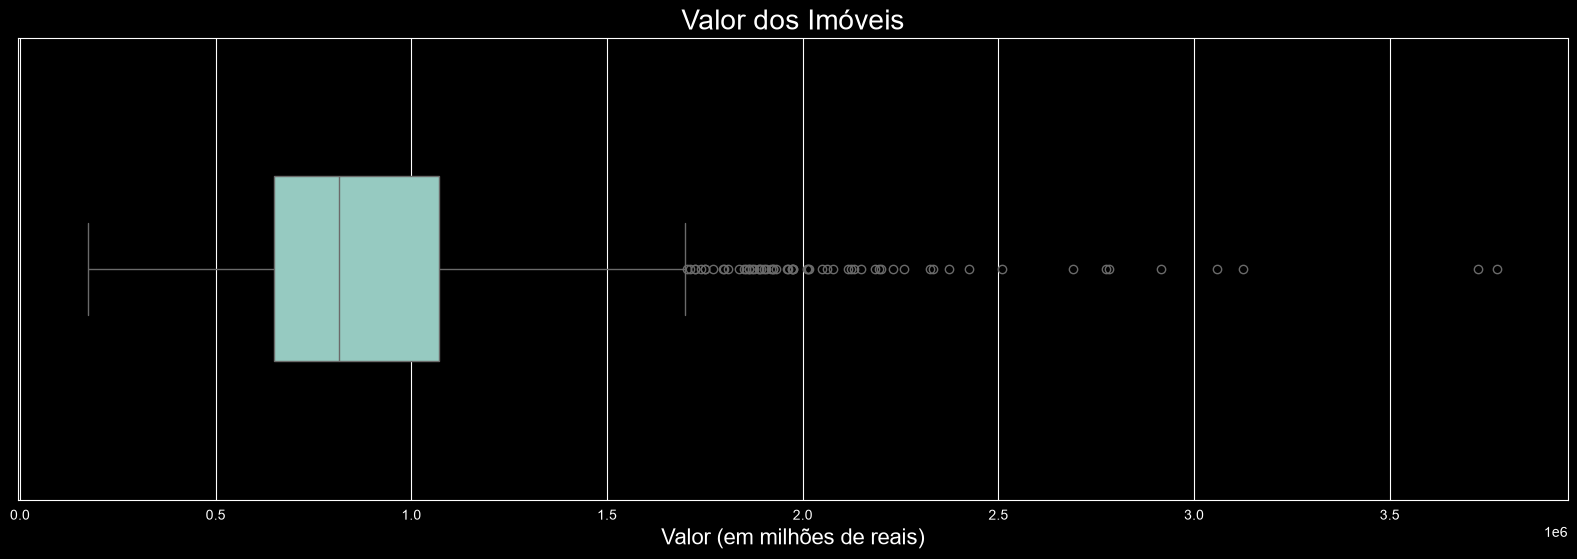

In [23]:
ax = sns.boxplot(dados, x ="valor", width=0.4)

ax.figure.set_size_inches(20, 6)
ax.set_title('Valor dos Imóveis', fontsize=20)
ax.set_xlabel('Valor (em milhões de reais)', fontsize=16)
plt.show()

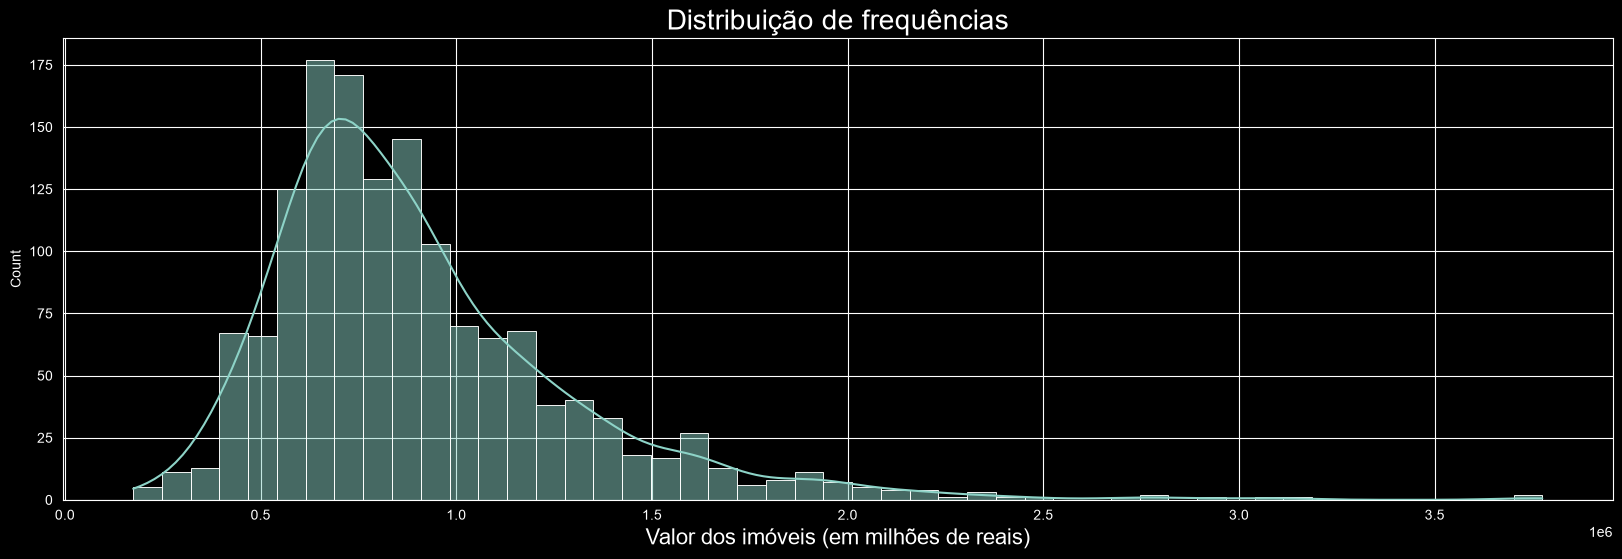

In [24]:
ax = sns.histplot(dados['valor'], kde=True)

ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequências', fontsize=20)
ax.set_xlabel('Valor dos imóveis (em milhões de reais)', fontsize=16)
plt.show()

# Gráfico de Densidade

Um gráfico de densidade é uma versão suavizada do histograma, utilizando uma função de densidade para estimar a distribuição de uma variável contínua. Diferente do histograma, que usa "bins" para agrupar os dados, o gráfico de densidade cria uma curva contínua que representa essa distribuição.

Os três tipos básicos de um gráfico de densidade são:

### 1. Distribuição Assimétrica à Direita (Positivamente Assimétrica)
* A cauda longa da curva está localizada à **direita** da mediana.
* Neste caso, a **média** dos dados é **maior** que a mediana ($\text{Média} > \text{Mediana}$).

### 2. Distribuição Simétrica
* A distribuição é espelhada e equilibrada em torno das medidas de tendência central.
* A característica principal é que a **média**, a **mediana** e a **moda** são iguais ou muito próximas ($\text{Média} \approx \text{Mediana} \approx \text{Moda}$).

### 3. Distribuição Assimétrica à Esquerda (Negativamente Assimétrica)
* A cauda longa da curva está localizada à **esquerda** da mediana.
* Neste caso, a **média** dos dados é **menor** que a mediana ($\text{Média} < \text{Mediana}$).


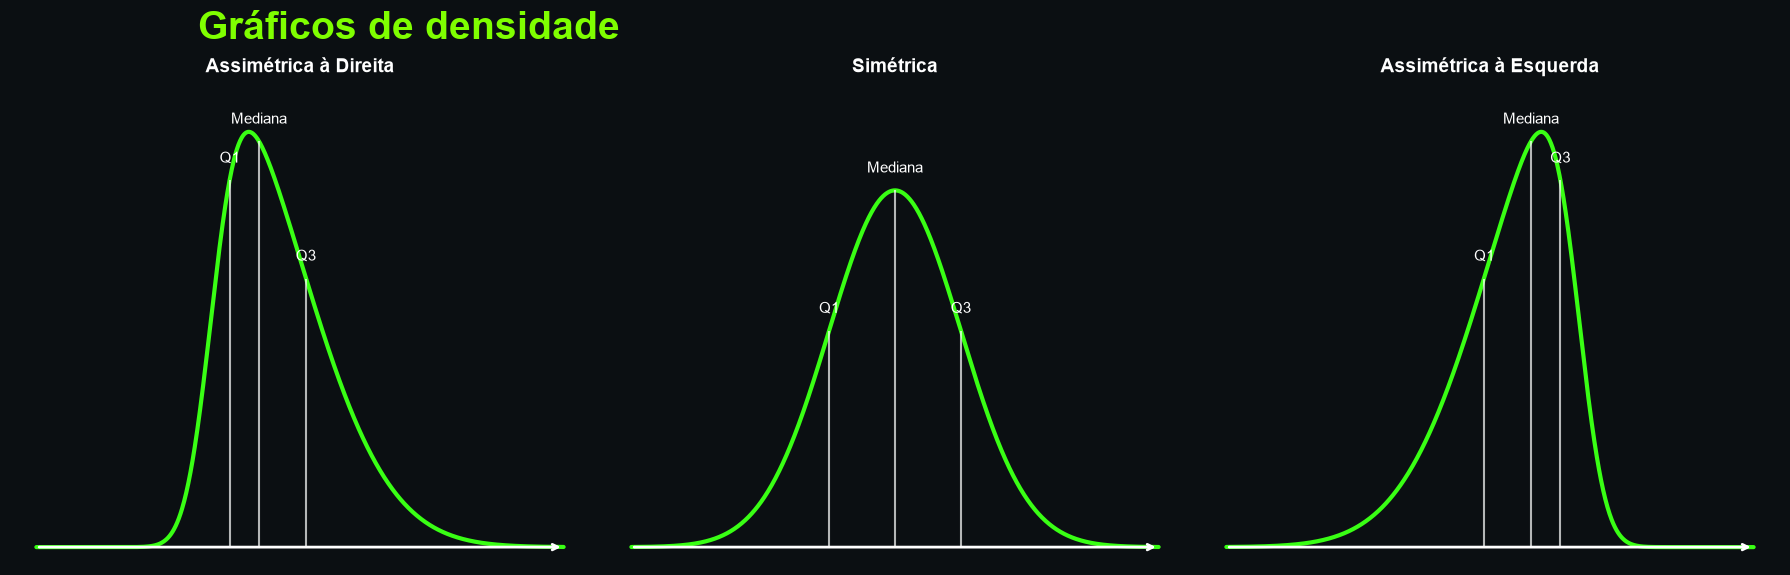

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm, norm

# Configura o estilo visual escuro idêntico ao slide do curso
plt.style.use('dark_background')

# Cria a figura com um tamanho grande e nítido
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0B0F12')

# Título principal do slide adicionado no topo da figura geral
fig.suptitle('Gráficos de densidade', fontsize=28, weight='bold', color='#7FFF00', x=0.23, y=0.95)

# Configurações de dados para gerar as curvas suavizadas
x_sym = np.linspace(-4, 4, 1000)
y_sym = norm.pdf(x_sym, 0, 1)

x_right = np.linspace(-2, 7, 1000)
y_right = skewnorm.pdf(x_right, 4, 1, 1.5)

x_left = np.linspace(-7, 2, 1000)
y_left = skewnorm.pdf(x_left, -4, -1, 1.5)

# --- 1. CURVA ASSIMÉTRICA À DIREITA ---
ax = axes[0]
ax.set_facecolor('#0B0F12')
ax.plot(x_right, y_right, color='#39FF14', linewidth=3)
ax.set_title('Assimétrica à Direita', fontsize=14, weight='bold', pad=20)
# Linhas verticais para Q1, Mediana (Q2) e Q3 baseadas no formato visual do slide
ax.vlines(x=1.3, ymin=0, ymax=y_right[np.abs(x_right - 1.3).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=1.8, ymin=0, ymax=y_right[np.abs(x_right - 1.8).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=2.6, ymin=0, ymax=y_right[np.abs(x_right - 2.6).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.text(1.3, y_right[np.abs(x_right - 1.3).argmin()]+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(1.8, y_right[np.abs(x_right - 1.8).argmin()]+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(2.6, y_right[np.abs(x_right - 2.6).argmin()]+0.02, 'Q3', fontsize=11, color='white', ha='center')
# Seta do eixo X
ax.annotate('', xy=(7, 0), xytext=(-2, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# --- 2. CURVA SIMÉTRICA ---
ax = axes[1]
ax.set_facecolor('#0B0F12')
ax.plot(x_sym, y_sym, color='#39FF14', linewidth=3)
ax.set_title('Simétrica', fontsize=14, weight='bold', pad=20)
ax.vlines(x=-1.0, ymin=0, ymax=norm.pdf(-1.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=0.0, ymin=0, ymax=norm.pdf(0.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=1.0, ymin=0, ymax=norm.pdf(1.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.text(-1.0, norm.pdf(-1.0, 0, 1)+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(0.0, norm.pdf(0.0, 0, 1)+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(1.0, norm.pdf(1.0, 0, 1)+0.02, 'Q3', fontsize=11, color='white', ha='center')
ax.annotate('', xy=(4, 0), xytext=(-4, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# --- 3. CURVA ASSIMÉTRICA À ESQUERDA ---
ax = axes[2]
ax.set_facecolor('#0B0F12')
ax.plot(x_left, y_left, color='#39FF14', linewidth=3)
ax.set_title('Assimétrica à Esquerda', fontsize=14, weight='bold', pad=20)
ax.vlines(x=-2.6, ymin=0, ymax=y_left[np.abs(x_left - -2.6).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=-1.8, ymin=0, ymax=y_left[np.abs(x_left - -1.8).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=-1.3, ymin=0, ymax=y_left[np.abs(x_left - -1.3).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.text(-2.6, y_left[np.abs(x_left - -2.6).argmin()]+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(-1.8, y_left[np.abs(x_left - -1.8).argmin()]+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(-1.3, y_left[np.abs(x_left - -1.3).argmin()]+0.02, 'Q3', fontsize=11, color='white', ha='center')
ax.annotate('', xy=(2, 0), xytext=(-7, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# Limpeza estética geral (remove bordas desnecessárias)
for ax in axes:
    ax.set_ylim(-0.02, 0.5)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()


In [26]:
dados.columns

Index(['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque'],
      dtype='str')

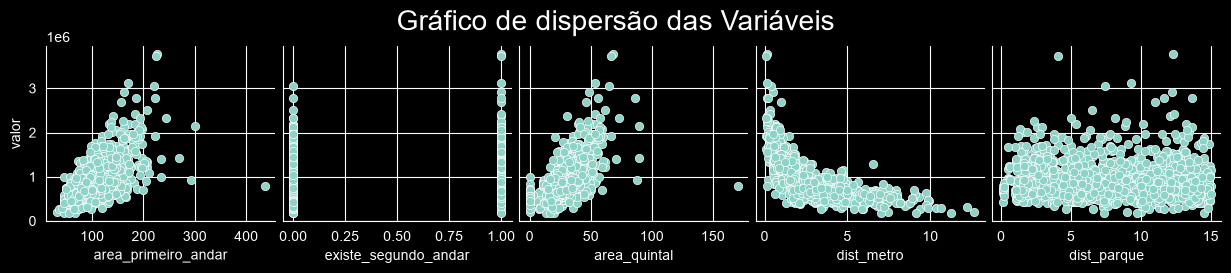

In [27]:
ax = sns.pairplot(dados, y_vars="valor", x_vars= ['area_primeiro_andar','existe_segundo_andar','area_quintal', 'dist_metro', 'dist_parque'])
ax.figure.suptitle('Gráfico de dispersão das Variáveis', fontsize=20, y=1.05)
plt.show()

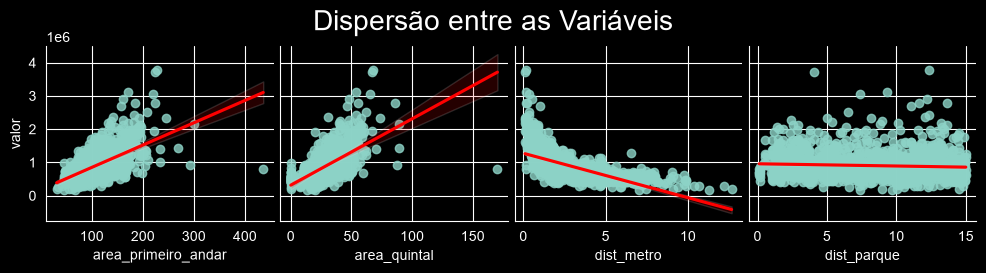

In [28]:
ax = sns.pairplot(dados, y_vars="valor", x_vars= ['area_primeiro_andar','area_quintal', 'dist_metro', 'dist_parque'],
                  kind='reg', plot_kws={'line_kws':{'color':'red'}})
ax.figure.suptitle('Dispersão entre as Variáveis', fontsize=20, y=1.05)
plt.show()

In [29]:
# Verificando se há 0 nas variáveis explicativas do nosso df
dados.describe().round(2)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,904605.98,108.01,0.43,29.47,2.77,8.15
std,397212.51,35.92,0.50,12.23,1.91,4.20
min,174500.00,31.03,0.00,0.00,0.10,0.12
25%,649875.00,81.94,0.00,22.18,1.42,4.44
50%,815000.00,100.98,0.00,27.64,2.26,8.73
75%,1070000.00,129.25,1.00,36.18,3.89,11.64
max,3775000.00,435.90,1.00,170.29,12.65,15.00


In [30]:
# Transformando as variáveis explicativas e resposta utilizando o logaritmo
dados['log_valor'] = np.log(dados['valor'])
dados['log_area_primeiro_andar'] = np.log(dados['area_primeiro_andar'])
dados['log_area_quintal'] = np.log1p(dados['area_quintal'])
dados['log_dist_metro'] = np.log(dados['dist_metro'])
dados['log_dist_parque'] = np.log(dados['dist_parque'])

In [31]:
# Lendo os dados
dados.head(3)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque,log_valor,log_area_primeiro_andar,log_area_quintal,log_dist_metro,log_dist_parque
0,1042500,79.52,1,23.86,1.64,3.04,13.857132,4.376009,3.213260,0.494696,1.111858
1,907500,117.24,0,35.17,1.54,10.91,13.718449,4.764223,3.588230,0.431782,2.389680
2,1117500,85.47,1,25.64,1.27,11.79,13.926605,4.448165,3.282414,0.239017,2.467252


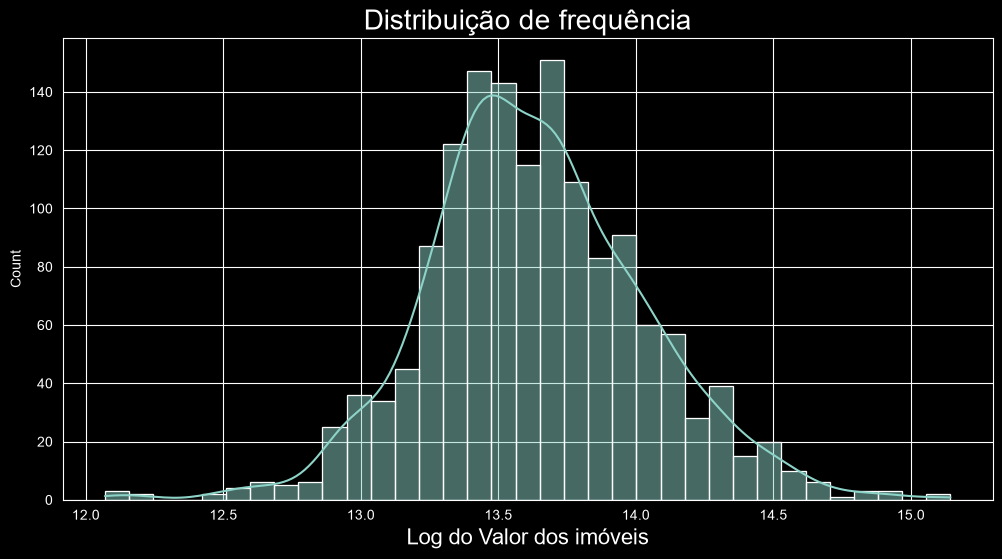

In [32]:
ax = sns.histplot(dados['log_valor'], kde=True)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Valor dos imóveis', fontsize=16)
plt.show()